# Blueberry Yield Prediction

**Goal:** Fit a regression model to predict blueberry `yield` from the training data, then predict on the test data.
**Evaluation metric:** Mean Absolute Error (MAE).

Models explored: Linear, Polynomial, Ridge, Lasso, and Elastic Net regression.


## 1. Imports

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

## 2. Load Data

The training set has the target `yield`; the test set does not.

In [25]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (15289, 18)
Test shape: (10194, 17)


,id,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield
0,0,25.0,0.50,0.25,0.75,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.425011,0.417545,32.460887,4476.81146
1,1,25.0,0.50,0.25,0.50,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.444908,0.422051,33.858317,5548.12201
2,2,12.5,0.25,0.25,0.63,0.63,86.0,52.0,71.9,62.0,30.0,50.8,24.0,0.39,0.552927,0.470853,38.341781,6869.77760
3,3,12.5,0.25,0.25,0.63,0.50,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.565976,0.478137,39.467561,6880.77590
4,4,25.0,0.50,0.25,0.63,0.63,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.579677,0.494165,40.484512,7479.93417


In [26]:
test.head()

,id,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds
0,15289,25.0,0.25,0.25,0.25,0.25,86.0,52.0,71.9,62.0,30.0,50.8,24.0,0.39,0.399367,0.408088,31.394569
1,15290,12.5,0.25,0.25,0.75,0.63,94.6,57.2,79.0,68.2,33.0,55.9,1.0,0.10,0.488048,0.442866,36.846956
2,15291,12.5,0.25,0.25,0.63,0.63,86.0,52.0,71.9,62.0,30.0,50.8,16.0,0.26,0.583379,0.487057,40.037644
3,15292,25.0,0.50,0.38,0.38,0.63,86.0,52.0,71.9,62.0,30.0,50.8,16.0,0.26,0.433014,0.422847,33.116091
4,15293,37.5,0.75,0.25,0.25,0.25,94.6,57.2,79.0,68.2,33.0,55.9,24.0,0.39,0.360996,0.388860,29.558019


## 3. Explore the Data

Check for missing values, data types, and the target distribution.

In [27]:
print(train.isnull().sum().sum(), "missing values total")
print(test.isnull().sum().sum(), "missing values total")
print(train.dtypes.value_counts())
print(train["yield"].describe())

0 missing values total
0 missing values total
float64    17
int64       1
Name: count, dtype: int64
count    15289.000000
mean      6025.193999
std       1337.056850
min       1945.530610
25%       5128.163510
50%       6117.475900
75%       7019.694380
max       8969.401840
Name: yield, dtype: float64


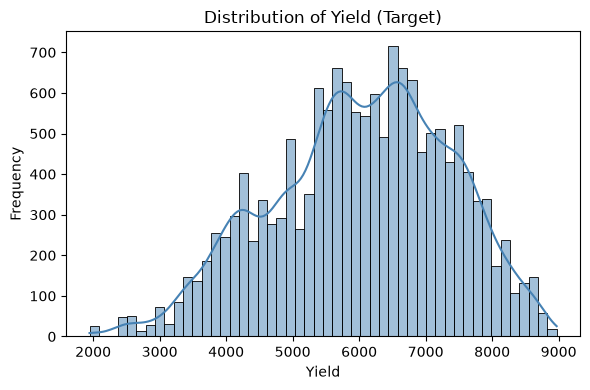

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
plt.figure(figsize=(6, 4))
sns.histplot(train["yield"], bins=50, kde=True, color="steelblue")
plt.title("Distribution of Yield (Target)")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

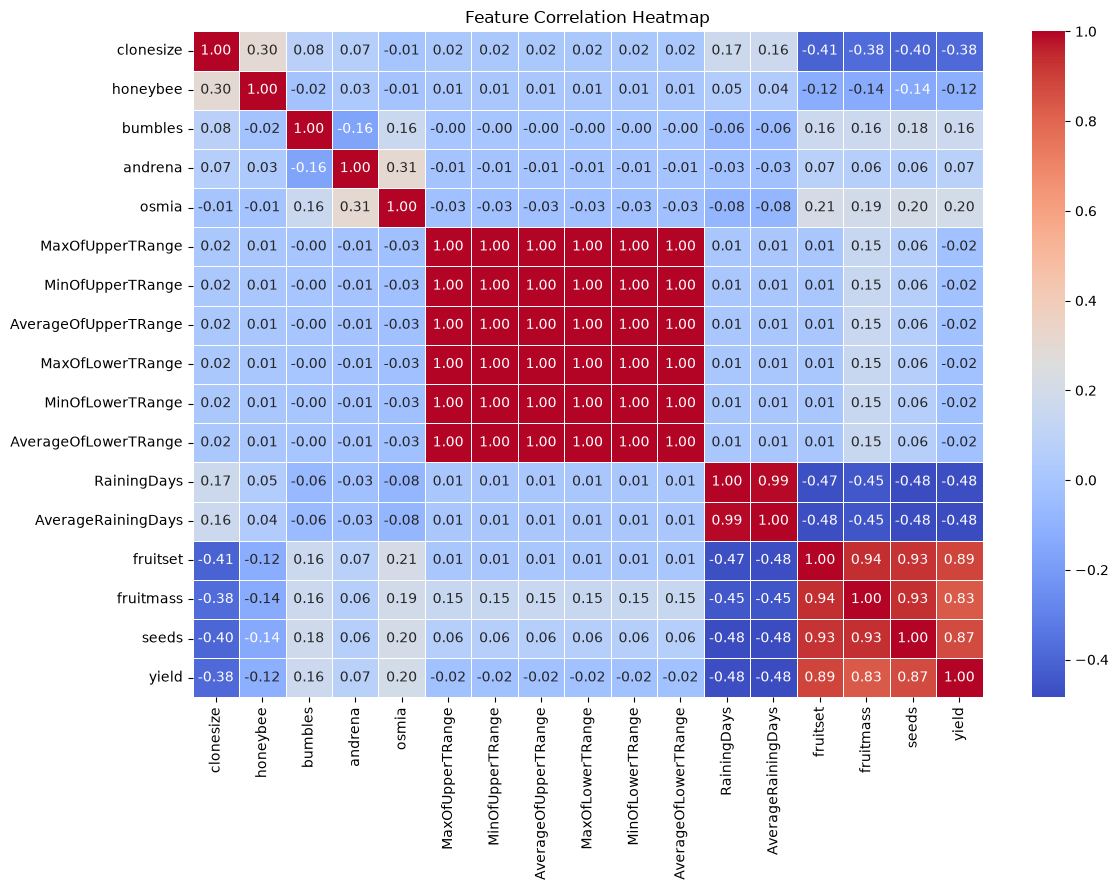

In [20]:
# Correlation heatmap
plt.figure(figsize=(12, 9))
corr = train.drop(columns=["id"]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [30]:
# Top features correlated with yield
print(corr["yield"].drop("yield").sort_values(ascending=False).to_string())

fruitset                0.885967
seeds                   0.868853
fruitmass               0.826481
osmia                   0.198264
bumbles                 0.161145
andrena                 0.073969
MinOfUpperTRange       -0.021929
AverageOfUpperTRange   -0.021940
AverageOfLowerTRange   -0.022081
MaxOfLowerTRange       -0.022197
MinOfLowerTRange       -0.022319
MaxOfUpperTRange       -0.022517
honeybee               -0.118001
clonesize              -0.382619
RainingDays            -0.477191
AverageRainingDays     -0.483870


## 4. Define Features and Target

The `id` column is an identifier and should not be used as a feature.

In [34]:
feature_cols = [c for c in train.columns if c not in ("id", "yield")]
target = "yield"

X = train[feature_cols]
y = train[target]
X_test = test[feature_cols]

print("Features:", feature_cols)
print("X shape:", X.shape, "| X_test shape:", X_test.shape)

Features: ['clonesize', 'honeybee', 'bumbles', 'andrena', 'osmia', 'MaxOfUpperTRange', 'MinOfUpperTRange', 'AverageOfUpperTRange', 'MaxOfLowerTRange', 'MinOfLowerTRange', 'AverageOfLowerTRange', 'RainingDays', 'AverageRainingDays', 'fruitset', 'fruitmass', 'seeds']
X shape: (15289, 16) | X_test shape: (10194, 16)


## 5. Train / Validation Split

We hold out part of the training data as a validation set to compare models.

In [32]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("X_train:", X_train.shape, "| X_val:", X_val.shape)

X_train: (12231, 16) | X_val: (3058, 16)


## 6. Data Preparation

All features are numeric, so no categorical encoding is needed. Missing values are dropped/checked, and we **standardize** features (fit on training, transformed consistently for validation and test).

We build small pipelines so the **same** scaling is applied to train and test.


In [33]:
# Verify there are no missing values to handle
print("Missing in X_train:", X_train.isnull().sum().sum())
print("Missing in X_test:", X_test.isnull().sum().sum())

Missing in X_train: 0
Missing in X_test: 0


## 7. Linear Regression (Baseline)

In [12]:
lin_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])
lin_pipe.fit(X_train, y_train)
y_pred = lin_pipe.predict(X_val)
mae = mean_absolute_error(y_val, y_pred)
print(f"Linear Regression validation MAE: {mae:.4f}")

Linear Regression validation MAE: 370.4475


## 8. Polynomial Regression

Add polynomial (interaction) features of degree 2.

In [13]:
from sklearn.model_selection import cross_val_score

def evaluate(pipeline, name):
    mae = -cross_val_score(
        pipeline, X, y, cv=5,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    ).mean()
    print(f"{name}: val MAE (5-fold CV) = {mae:.4f}")
    return mae

for degree in [2]:
    poly_pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ])
    evaluate(poly_pipe, f"Polynomial (degree {degree})")

Polynomial (degree 2): val MAE (5-fold CV) = 392.8008


## 9. Regularized Models: Ridge, Lasso, Elastic Net

We tune the regularization strength `alpha` with cross-validation.

In [14]:
from sklearn.model_selection import GridSearchCV

# Ridge
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge()),
])
ridge_cv = GridSearchCV(ridge, {"model__alpha": [0.1, 1, 10, 100]},
                        scoring="neg_mean_absolute_error", cv=5, n_jobs=-1)
ridge_cv.fit(X, y)
print("Ridge best alpha:", ridge_cv.best_params_)
print(f"Ridge best val MAE: {-ridge_cv.best_score_:.4f}")

# Lasso
lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=100000)),
])
lasso_cv = GridSearchCV(lasso, {"model__alpha": [0.1, 1, 10, 100]},
                        scoring="neg_mean_absolute_error", cv=5, n_jobs=-1)
lasso_cv.fit(X, y)
print("Lasso best alpha:", lasso_cv.best_params_)
print(f"Lasso best val MAE: {-lasso_cv.best_score_:.4f}")

# Elastic Net
enet = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=100000)),
])
enet_cv = GridSearchCV(enet, {"model__alpha": [0.1, 1, 10, 100],
                              "model__l1_ratio": [0.2, 0.5, 0.8]},
                       scoring="neg_mean_absolute_error", cv=5, n_jobs=-1)
enet_cv.fit(X, y)
print("Elastic Net best params:", enet_cv.best_params_)
print(f"Elastic Net best val MAE: {-enet_cv.best_score_:.4f}")

Ridge best alpha: {'model__alpha': 1}
Ridge best val MAE: 372.0910
Lasso best alpha: {'model__alpha': 1}
Lasso best val MAE: 371.9492
Elastic Net best params: {'model__alpha': 0.1, 'model__l1_ratio': 0.8}
Elastic Net best val MAE: 376.0599


## 10. Compare Models by MAE

We collect all validation MAE scores to pick the best model.

In [36]:
results = {
    "Linear Regression": lin_pipe,
}

# Re-evaluate best models on the validation split for a fairer comparison
def val_mae(pipeline, name):
    mae = mean_absolute_error(y_val, pipeline.predict(X_val))
    print(f"{name}: validation MAE = {mae:.4f}")

val_mae(lin_pipe, "Linear Regression")
val_mae(ridge_cv.best_estimator_, "Ridge")
val_mae(lasso_cv.best_estimator_, "Lasso")
val_mae(enet_cv.best_estimator_, "Elastic Net")

Linear Regression: validation MAE = 370.4475
Ridge: validation MAE = 370.3245
Lasso: validation MAE = 370.3632
Elastic Net: validation MAE = 374.5526


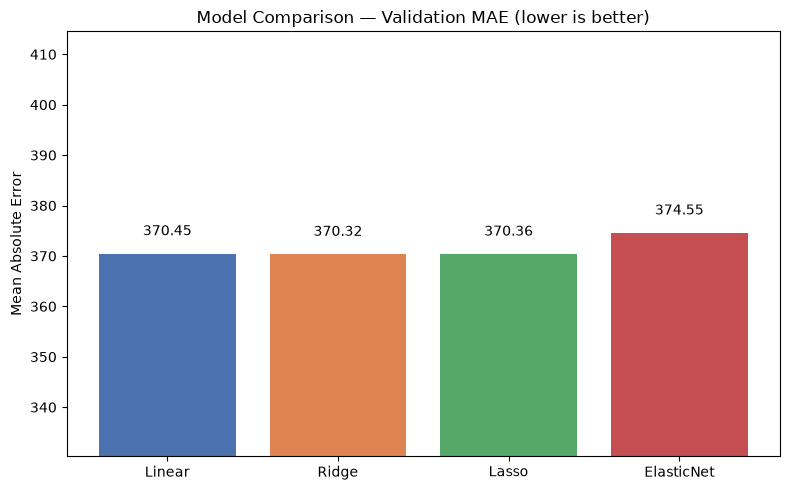

In [35]:
# Plot model comparison
names = ["Linear", "Ridge", "Lasso", "ElasticNet"]
maes = [
    mean_absolute_error(y_val, lin_pipe.predict(X_val)),
    mean_absolute_error(y_val, ridge_cv.best_estimator_.predict(X_val)),
    mean_absolute_error(y_val, lasso_cv.best_estimator_.predict(X_val)),
    mean_absolute_error(y_val, enet_cv.best_estimator_.predict(X_val)),
]

plt.figure(figsize=(8, 5))
bars = plt.bar(names, maes, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
plt.title("Model Comparison — Validation MAE (lower is better)")
plt.ylabel("Mean Absolute Error")
plt.ylim(min(maes) - 40, max(maes) + 40)
for b, m in zip(bars, maes):
    plt.text(b.get_x() + b.get_width() / 2, b.get_height() + 3,
             f"{m:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 11. Select Best Model

Based on validation MAE, we choose the best-performing model and retrain on the full training set.

*(If a polynomial model performs best, we train one here — otherwise we use the best regularized model.)*

Selected model: Ridge
Validation MAE: 370.3245


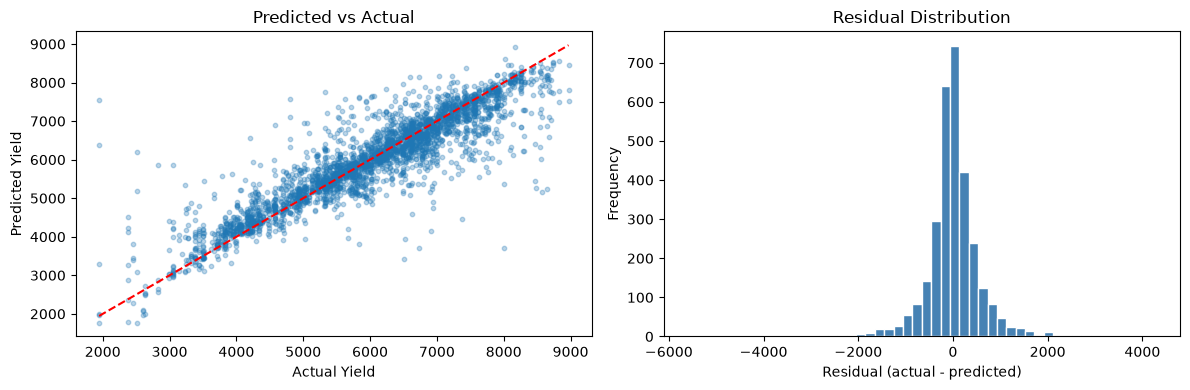

In [38]:
# By default use the best regularized model (adjust based on results above)
best_model = ridge_cv.best_estimator_

print("Selected model: Ridge")
print(f"Validation MAE: {mean_absolute_error(y_val, best_model.predict(X_val)):.4f}")

# Residuals on the validation set
y_val_pred = best_model.predict(X_val)
residuals = y_val - y_val_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Predicted vs Actual
axes[0].scatter(y_val, y_val_pred, alpha=0.3, s=10)
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--")
axes[0].set_xlabel("Actual Yield")
axes[0].set_ylabel("Predicted Yield")
axes[0].set_title("Predicted vs Actual")

# Residuals histogram
axes[1].hist(residuals, bins=50, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Residual (actual - predicted)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

## 12. Generate Submission

Predict on the test set and write the submission CSV with `id` and `yield` columns.

In [39]:
test_pred = best_model.predict(X_test)

submission = pd.DataFrame({
    "id": test["id"],
    "yield": test_pred,
})

submission.to_csv("submission.csv", index=False)
print("submission.csv written")
print("Shape:", submission.shape)
submission.head()

submission.csv written
Shape: (10194, 2)


,id,yield
0,15289,4310.869359
1,15290,6103.339248
2,15291,7257.079313
3,15292,4981.632216
4,15293,3672.506679


## Summary

We compared linear, polynomial, ridge, lasso, and elastic net regression using MAE on a validation set. The best model was used to generate `submission.csv` (columns: `id`, `yield`), which can be submitted to Kaggle.

To upload: go to the project's Kaggle page and submit `submission.csv`.
